### Objetivos

1. Carregar e processar arquivos de seis formatos diferentes (`.csv`, `.json`, `.jsonl`, `.md`, `.pdf`, `.txt`).
2. Aplicar **chunking adaptativo** - uma estratégia por natureza de documento, não uma configuração única para tudo.
3. Anexar um **schema de metadados padronizado** a cada chunk.
4. Vetorizar e indexar em FAISS, **persistindo o índice em disco**.

### Chunking adaptativo - o que se espera

Não trate tudo como texto corrido. A regra de decisão é a **unidade semântica mínima** de cada fonte:
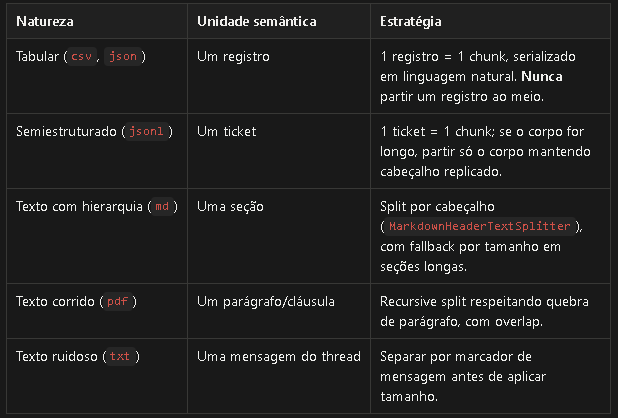

## Serialização de registro tabular - o objetivo é gerar texto que um embedding entenda:

❌ ruim:  "1042,Maria Souza,MG,estoque,2024-03-12,ativo"
✅ bom:   "Cliente 1042: Maria Souza, estado MG, módulo contratado estoque,
           cliente desde 2024-03-12, situação ativo."

### Schema de metadados obrigatório

Todo chunk, de toda fonte, carrega no mínimo:

{
    "source_file": str,      # nome do arquivo de origem

    "doc_type": str,         # customer | employee | product | store | ticket | log | manual | ata | policy | email

    "chunk_id": str,         # identificador único e estável

    "sensitivity": str,      # publico | interno | restrito
}

### Campos adicionais quando aplicáveis: `customer_id`, `state`, `module`, `priority`, `status`, `date`, `section`.

- `sensitivity` **é o campo que sustenta a Etapa 3.** Classifique na ingestão, não na hora de responder - filtrar por metadado é barato e determinístico; pedir para o LLM decidir depois é caro e falível.


### Critério de pronto

- [ ]  Um leitor implementado e testado para cada um dos 6 formatos.
- [ ]  Schema de metadados aplicado uniformemente (verificável: nenhum chunk sem `doc_type` ou `sensitivity`).
- [ ]  Índice FAISS populado e salvo em disco (`save_local`), com script de recarga (`load_local`) que **não** reindexa.
- [ ]  Script de sanidade que imprime: total de chunks, distribuição por `doc_type`, e os 5 chunks mais similares para 3 perguntas de teste (liste as 3 perguntas).

### Instalação das bibliotecas de Embedding e FAISS

In [1]:
!pip install sentence-transformers
!pip install faiss-cpu
!pip install langchain-core==0.1.53 --force-reinstall # Garante uma versão compatível de langchain-core
# Instalar a biblioteca langchain-text-splitters
!pip install langchain-text-splitters==0.0.1 # Ensure this specific version is used

  Using cached langchain_core-0.1.53-py3-none-any.whl.metadata (5.9 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langsmith-0.1.147-py3-none-any.whl.metadata (14 kB)
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached tenacity-8.5.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached orjson-3.12.0-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (41 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached pyda

  Using cached langchain_text_splitters-0.0.1-py3-none-any.whl.metadata (2.0 kB)
Using cached langchain_text_splitters-0.0.1-py3-none-any.whl (21 kB)
ERROR: Operation cancelled by user
^C


In [23]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.1/385.1 kB 4.9 MB/s eta 0:00:00


### Extraindo arquivos dos diretórios zipados

Vamos descompactar os arquivos `structured.zip` e `unstructured.zip` para acessar os documentos `.md` e `.txt`.

In [24]:
import zipfile
import os
import json
import pandas as pd
from langchain_community.document_loaders import PyPDFLoader

# Caminhos para os arquivos zip
zip_structured = '/content/structured.zip'
zip_unstructured = '/content/unstructured.zip'
zip_semi_structured = '/content/semi_structured.zip'

# Diretórios de destino para extração
extract_dir_structured = '/content/extracted_structured'
extract_dir_unstructured = '/content/extracted_unstructured'
extract_dir_semi_structured = '/content/extracted_semi_structured'

# Criar diretórios de destino se não existirem
os.makedirs(extract_dir_structured, exist_ok=True)
os.makedirs(extract_dir_unstructured, exist_ok=True)
os.makedirs(extract_dir_semi_structured, exist_ok=True)

# Extrair structured.zip
print(f"Extraindo {zip_structured} para {extract_dir_structured}...")
with zipfile.ZipFile(zip_structured, 'r') as zip_ref:
    zip_ref.extractall(extract_dir_structured)
print("Extração de structured.zip concluída.")

# Extrair unstructured.zip
print(f"Extraindo {zip_unstructured} para {extract_dir_unstructured}...")
with zipfile.ZipFile(zip_unstructured, 'r') as zip_ref:
    zip_ref.extractall(extract_dir_unstructured)
print("Extração de unstructured.zip concluída.")

# Extrair semi-structured.zip
print(f"Extraindo {zip_semi_structured} para {extract_dir_semi_structured}...")
with zipfile.ZipFile(zip_semi_structured, 'r') as zip_ref:
    zip_ref.extractall(extract_dir_semi_structured)
print("Extração de semi_structured.zip concluída.")

Extraindo /content/structured.zip para /content/extracted_structured...
Extração de structured.zip concluída.
Extraindo /content/unstructured.zip para /content/extracted_unstructured...
Extração de unstructured.zip concluída.
Extraindo /content/semi_structured.zip para /content/extracted_semi_structured...
Extração de semi_structured.zip concluída.


### Leitura e Chunking de Arquivos `.md` e `.txt`

Ler o conteúdo dos arquivos Markdown (`.md`) e texto (`.txt`) e transformá-los em chunks com seus respectivos metadados.

Para estes tipos de documentos, foi utilizada a estratégia de `RecursiveCharacterTextSplitter`. Esta abordagem tenta dividir o texto em pedaços menores de forma inteligente, mantendo a coerência semântica. Os parâmetros usados são:

- `chunk_size=1000`: Cada chunk terá aproximadamente 1000 caracteres.
- `chunk_overlap=200`: Haverá uma sobreposição de 200 caracteres entre os chunks consecutivos. Isso ajuda a preservar o contexto entre os chunks, minimizando a perda de informação em suas fronteiras.

Esta estratégia visa dividir documentos longos em unidades gerenciáveis, enquanto o `chunk_overlap` garante que nenhum contexto crítico seja perdido nas transições.

### Chunking Adaptativo para Arquivos de Código


## Estratégia usada por tipo de arquivo

| Tipo           | Estratégia                                       | Unidade transformada em chunk                |
| -------------- | ------------------------------------------------ | -------------------------------------------- |
| `.md` / `.txt` | `TextLoader` + `RecursiveCharacterTextSplitter`  | Trechos de texto de até ~1000 caracteres     |
| `.pdf`         | `PyPDFLoader` + `RecursiveCharacterTextSplitter` | Texto extraído das páginas e depois dividido |
| `.jsonl`       | Leitura linha a linha com `json.loads()`         | Cada linha JSON vira um chunk                |
| `.json`        | `json.load()` e iteração sobre registros         | Cada objeto JSON vira um chunk               |
| `.csv`         | `pandas.read_csv()` e iteração por linhas        | Cada linha da tabela vira um chunk           |


In [25]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import json
import os
import re
import pandas as pd

def process_file(filepath, base_dir):
    file_extension = os.path.splitext(filepath)[1]
    filename = os.path.basename(filepath)

    # Default values
    doc_type = 'manual'
    sensitivity = 'publico'
    parent_category = None
    customer_id = None
    ticket_id = None
    meeting_year_month = None # Novo campo para ano/mês da reunião

    # 1. Determine parent_category (primarily for unstructured)
    if 'unstructured' in base_dir:
        effective_base_path = os.path.join(base_dir, 'unstructured')
        if os.path.exists(effective_base_path):
            relative_to_unstructured_base = os.path.relpath(filepath, effective_base_path)
            if os.sep in relative_to_unstructured_base:
                parent_category = relative_to_unstructured_base.split(os.sep)[0]

    # 2. Determine doc_type and sensitivity based on parent_category or directory structure
    if parent_category == 'emails':
        doc_type = 'email'
        sensitivity = 'interno' # Default for emails
        if filename.startswith('customer_'):
            sensitivity = 'restrito' # Specific for customer emails
            customer_id = f"CUST{filename.split('_')[1].split('.')[0]}" # Extract customer_id
        elif 'ticket_' in filename: # Emails can also be related to tickets
            ticket_id = f"TCK{filename.split('_')[1].split('.')[0]}" # Extract ticket_id
    elif parent_category == 'meetings':
        doc_type = 'ata'
        sensitivity = 'interno'
        # Extrair ano e mês do nome do arquivo (ex: 2026-02-meeting_description.md)
        match = re.match(r'(\d{4}-\d{2})-.*', filename)
        if match:
            meeting_year_month = match.group(1)

    elif parent_category == 'policies':
        doc_type = 'policy'
        sensitivity = 'interno'
    elif parent_category == 'documentation':
        sub_dir_parts = relative_to_unstructured_base.split(os.sep)
        if len(sub_dir_parts) > 1 and sub_dir_parts[1] in ['pdv', 'pay', 'analytics', 'estoque', 'ecommerce']:
            doc_type = sub_dir_parts[1]
            sensitivity = 'interno'
        else:
            doc_type = 'manual'
            sensitivity = 'publico'
    elif 'structured' in base_dir: # For structured files (mostly .csv, .json, but for .md/.txt too if found)
        # Original logic for structured files
        parent_dir = os.path.basename(os.path.dirname(filepath))
        if parent_dir in ['pdv', 'pay', 'analytics', 'estoque', 'ecommerce']:
            doc_type = parent_dir
            sensitivity = 'interno'
        if filename.startswith('internal_'):
            doc_type = 'policy'
            sensitivity = 'interno'

    # Fallback for generic files or patterns not covered by parent_category
    # Only apply these if doc_type is still 'manual' (its default state) AND not already processed via parent_category emails/tickets
    if doc_type == 'manual': # This means no specific category or structured rule applied yet
        if filename.startswith('customer_'):
            doc_type = 'customer'
            sensitivity = 'restrito'
            customer_id = f"CUST{filename.split('_')[1].split('.')[0]}"
        elif 'ticket_' in filename:
            doc_type = 'ticket'
            sensitivity = 'restrito'
            ticket_id = f"TCK{filename.split('_')[1].split('.')[0]}"
        elif filename.startswith('internal_'):
            doc_type = 'policy'
            sensitivity = 'interno'

    # Load the document content
    loader = TextLoader(filepath, encoding='utf-8')
    documents = loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        length_function=len,
        is_separator_regex=False,
    )
    chunks = text_splitter.split_documents(documents)

    processed_chunks = []
    for i, chunk in enumerate(chunks):
        chunk_metadata = {
            "source_file": os.path.basename(filepath),
            "doc_type": doc_type,
            "chunk_id": f"{os.path.splitext(filename)[0]}-{i}",
            "sensitivity": sensitivity,
            **chunk.metadata # Preserve any metadata from the loader
        }

        if parent_category:
            chunk_metadata['parent_category'] = parent_category

        if customer_id:
            chunk_metadata['customer_id'] = customer_id
        if ticket_id:
            chunk_metadata['ticket_id'] = ticket_id
        if meeting_year_month: # Adicionar o novo metadado
            chunk_metadata['meeting_year_month'] = meeting_year_month

        processed_chunks.append({
            "page_content": chunk.page_content,
            "metadata": chunk_metadata
        })
    return processed_chunks

# New function for processing .jsonl files
def process_jsonl_file(filepath, base_dir):
    filename = os.path.basename(filepath)
    processed_chunks = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            try:
                data = json.loads(line)
                # Infer metadata for .jsonl files
                doc_type = 'record' # Generic type for semi-structured data
                sensitivity = 'interno' # Default

                # Attempt to infer more specific doc_type based on common fields in JSONL
                if 'review_score' in data and 'product_id' in data:
                    doc_type = 'product_review'
                    sensitivity = 'publico' # Product reviews might be public
                elif 'campaign_id' in data and 'email_subject' in data:
                    doc_type = 'email_campaign_log'
                    sensitivity = 'interno'
                elif 'ticket_id' in data and 'status' in data:
                    doc_type = 'ticket'
                    sensitivity = 'restrito'

                # Serialize the JSON object into a readable string for page_content
                # This can be made more sophisticated to extract key info into a sentence
                page_content = json.dumps(data, ensure_ascii=False, indent=2)

                chunk_metadata = {
                    "source_file": filename,
                    "doc_type": doc_type,
                    "chunk_id": f"{os.path.splitext(filename)[0]}-{i}",
                    "sensitivity": sensitivity,
                }
                if data.get('customer_id'):
                    chunk_metadata['customer_id'] = data['customer_id']
                if data.get('product_id'):
                    chunk_metadata['product_id'] = data['product_id']
                if data.get('timestamp'):
                    chunk_metadata['timestamp'] = data['timestamp']

                processed_chunks.append({
                    "page_content": page_content,
                    "metadata": chunk_metadata
                })
            except json.JSONDecodeError:
                print(f"Skipping invalid JSON line in {filepath}: {line.strip()}")
            except Exception as e:
                print(f"Error processing line in {filepath}: {e}, line: {line.strip()}")
    return processed_chunks

def process_csv_file(filepath, base_dir):
    filename = os.path.basename(filepath)
    processed_chunks = []
    try:
        df = pd.read_csv(filepath)
        for index, row in df.iterrows():
            # Serialize each row into a descriptive text string
            # Example: 'timestamp: 2024-03-01 08:00:00, level: INFO, service: Auth, ...'
            page_content = ", ".join(f"{col}: {row[col]}" for col in df.columns)

            # Infer metadata
            doc_type = 'log' # Default for system logs
            sensitivity = 'interno'
            if 'customer_id' in row and pd.notna(row['customer_id']): # Check for customer_id
                sensitivity = 'restrito'

            chunk_metadata = {
                "source_file": filename,
                "doc_type": doc_type,
                "chunk_id": f"{os.path.splitext(filename)[0]}-{index}",
                "sensitivity": sensitivity,
            }
            # Add specific metadata fields if they exist in the row
            if 'customer_id' in row and pd.notna(row['customer_id']):
                chunk_metadata['customer_id'] = row['customer_id']
            if 'service' in row and pd.notna(row['service']):
                chunk_metadata['service'] = row['service']
            if 'level' in row and pd.notna(row['level']): # Example: INFO, WARNING, ERROR
                chunk_metadata['level'] = row['level']
            if 'timestamp' in row and pd.notna(row['timestamp']): # Example: 2024-03-01 08:00:00
                chunk_metadata['timestamp'] = row['timestamp']

            processed_chunks.append({
                "page_content": page_content,
                "metadata": chunk_metadata
            })
    except Exception as e:
        print(f"Error processing CSV file {filepath}: {e}")
    return processed_chunks


def process_json_file(filepath, base_dir):
    filename = os.path.basename(filepath)
    processed_chunks = []

    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # Se o JSON for um único objeto, transforma em lista
        if isinstance(data, dict):
            records = [data]

        # Se já for uma lista de objetos
        elif isinstance(data, list):
            records = data

        else:
            print(f"Formato JSON não suportado em {filepath}")
            return processed_chunks

        for i, record in enumerate(records):

            # Caso algum elemento da lista não seja um dicionário
            if not isinstance(record, dict):
                page_content = str(record)

                chunk_metadata = {
                    "source_file": filename,
                    "doc_type": "record",
                    "chunk_id": f"{os.path.splitext(filename)[0]}-{i}",
                    "sensitivity": "interno",
                }

            else:
                # Valores padrão
                doc_type = "record"
                sensitivity = "interno"

                # Inferência do tipo de documento
                if 'review_score' in record and 'product_id' in record:
                    doc_type = 'product_review'
                    sensitivity = 'publico'

                elif 'campaign_id' in record and 'email_subject' in record:
                    doc_type = 'email_campaign_log'
                    sensitivity = 'interno'

                elif 'ticket_id' in record and 'status' in record:
                    doc_type = 'ticket'
                    sensitivity = 'restrito'

                # Converte o registro para texto
                page_content = json.dumps(
                    record,
                    ensure_ascii=False,
                    indent=2
                )

                chunk_metadata = {
                    "source_file": filename,
                    "doc_type": doc_type,
                    "chunk_id": f"{os.path.splitext(filename)[0]}-{i}",
                    "sensitivity": sensitivity,
                }

                # Metadados opcionais
                if record.get('customer_id'):
                    chunk_metadata['customer_id'] = record['customer_id']

                if record.get('product_id'):
                    chunk_metadata['product_id'] = record['product_id']

                if record.get('ticket_id'):
                    chunk_metadata['ticket_id'] = record['ticket_id']

                if record.get('timestamp'):
                    chunk_metadata['timestamp'] = record['timestamp']

            processed_chunks.append({
                "page_content": page_content,
                "metadata": chunk_metadata
            })

    except json.JSONDecodeError as e:
        print(f"JSON inválido em {filepath}: {e}")

    except Exception as e:
        print(f"Erro ao processar JSON {filepath}: {e}")

    return processed_chunks

def process_pdf_file(filepath, base_dir):
    filename = os.path.basename(filepath)

    loader = PyPDFLoader(filepath)
    documents = loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        length_function=len,
        is_separator_regex=False,
    )

    chunks = text_splitter.split_documents(documents)

    processed_chunks = []

    for i, chunk in enumerate(chunks):

        chunk_metadata = {
            "source_file": filename,
            "doc_type": "pdf",
            "chunk_id": f"{os.path.splitext(filename)[0]}-{i}",
            "sensitivity": "publico",
            **chunk.metadata
        }

        processed_chunks.append({
            "page_content": chunk.page_content,
            "metadata": chunk_metadata
        })

    return processed_chunks

md_txt_documents = []
jsonl_documents = []
json_documents = []
csv_documents = []
pdf_documents = []
all_documents = []



In [26]:
all_documents = []

directories_to_process = [
    extract_dir_structured,
    extract_dir_unstructured,
    extract_dir_semi_structured
]

print("Iniciando o processamento de arquivos com estratégias adaptativas...")

for base_dir in directories_to_process:
    for root, _, files in os.walk(base_dir):
        for file in files:

            filepath = os.path.join(root, file)
            file_extension = os.path.splitext(file)[1].lower()

            processed_chunks = []

            if file_extension in ('.md', '.txt'):
                print(f"Processando arquivo de texto/markdown: {filepath}")

                processed_chunks = process_file(
                    filepath,
                    base_dir
                )

            elif file_extension == '.pdf':
                print(f"Processando arquivo PDF: {filepath}")

                processed_chunks = process_pdf_file(
                    filepath,
                    base_dir
                )

            elif file_extension == '.jsonl':
                print(f"Processando arquivo JSONL: {filepath}")

                processed_chunks = process_jsonl_file(
                    filepath,
                    base_dir
                )

            elif file_extension == '.json':
                print(f"Processando arquivo JSON: {filepath}")

                processed_chunks = process_json_file(
                    filepath,
                    base_dir
                )

            elif file_extension == '.csv':
                print(f"Processando arquivo CSV: {filepath}")

                processed_chunks = process_csv_file(
                    filepath,
                    base_dir
                )

            else:
                print(
                    f"Ignorando arquivo com extensão não suportada: {filepath}"
                )

            all_documents.extend(processed_chunks)

print(
    f"\nProcessamento concluído. "
    f"Total de documentos/chunks coletados: {len(all_documents)}"
)

Iniciando o processamento de arquivos com estratégias adaptativas...
Processando arquivo CSV: /content/extracted_structured/structured/employees.csv
Processando arquivo JSON: /content/extracted_structured/structured/stores.json
Processando arquivo JSON: /content/extracted_structured/structured/products.json
Processando arquivo CSV: /content/extracted_structured/structured/sales.csv
Processando arquivo CSV: /content/extracted_structured/structured/customers.csv
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/documentation/pdv/hardware_e_perifericos.md
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/documentation/pdv/manual_pdv.md
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/documentation/pdv/troca_e_devolucao.md
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/documentation/pay/pix_dinamico_webhooks.md
Processando arquivo de texto/markdown: /c

Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/policies/beneficios_e_viagens.md
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/policies/seguranca_lgpd.md
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/policies/atendimento_sla.md
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/policies/reembolso.md
Processando arquivo PDF: /content/extracted_unstructured/unstructured/policies/reembolso.pdf
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/policies/home_office.md
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/meetings/2026-02-pdv_offline_contingency_test.md
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/meetings/2026-03-hr_performance_review_q1.md
Processando arquivo de texto/markdown: /content/extracted_unstructured/unstructured/meeting

### Criação do modelo de Embedding e Indexação FAISS

Modelo de `HuggingFaceEmbeddings` para gerar as representações vetoriais dos documentos e construção de um índice FAISS com eles.

In [27]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document # Importar Document para garantir compatibilidade
import os

# Definir o modelo de embedding
print("Carregando o modelo de embedding...")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)
print("Modelo de embedding carregado.")

# Converter os dicionários em objetos Document para FAISS
# O FAISS.from_documents espera uma lista de objetos Document
langchain_documents = [
    Document(page_content=doc['page_content'], metadata=doc['metadata'])
    for doc in all_documents
]


# Criar o índice FAISS a partir dos documentos
print(f"\nCriando o índice FAISS com {len(langchain_documents)} documentos...")
vector_store = FAISS.from_documents(langchain_documents, embeddings)
print("Índice FAISS criado com sucesso.")

# Definir o caminho para salvar o índice
faiss_index_path = "./faiss_index"

# Salvar o índice FAISS em disco
print(f"Salvando o índice FAISS em {faiss_index_path}...")
vector_store.save_local(faiss_index_path)
print("Índice FAISS salvo em disco.")

Carregando o modelo de embedding...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo de embedding carregado.

Criando o índice FAISS com 5638 documentos...
Índice FAISS criado com sucesso.
Salvando o índice FAISS em ./faiss_index...
Índice FAISS salvo em disco.


### Comprimir o diretorio com os indexes do FAISS
- download
- backup

In [28]:
import shutil
import os

# Caminho do diretório FAISS a ser compactado
faiss_dir_to_zip = './faiss_index'
# Nome do arquivo zip de saída (será salvo no /content/)
output_zip_filename = 'faiss_index'

print(f"Compactando o diretório '{faiss_dir_to_zip}' para '{output_zip_filename}.zip'...")

try:
    shutil.make_archive(output_zip_filename, 'zip', faiss_dir_to_zip)
    print(f"Diretório '{faiss_dir_to_zip}' compactado com sucesso em './{output_zip_filename}.zip'")
    print(f"Baixar o arquivo './{output_zip_filename}.zip' agora.")
except Exception as e:
    print(f"Erro ao compactar o diretório: {e}")


Compactando o diretório './faiss_index' para 'faiss_index.zip'...
Diretório './faiss_index' compactado com sucesso em './faiss_index.zip'
Baixar o arquivo './faiss_index.zip' agora.


### Recarregar e Testar o Índice FAISS

- enviar 3 queries de assuntos enncontrados nos documentos lidos.

In [30]:
# Testar uma busca por similaridade
query1 = "Quais ações foram aprovadas na meeting de 2026-02 sobre plano de retenção e mitigação de churn no varejo alimenticio ?"
#
query2 = "Quais os participantes na Ata de Reunião sobre Arquitetura de Banco de Dados e Cache Redis?"
#
query3 = "Qual a causa raiz do incidente sobre Queda do Serviço de TEF/Pay?"


In [32]:
# Recarregar o índice FAISS do disco
print(f"Recarregando o índice FAISS de {faiss_index_path}...")
loaded_vector_store = FAISS.load_local(faiss_index_path, embeddings, allow_dangerous_deserialization=True)
print("Índice FAISS recarregado com sucesso.")

query = query1
target_year_month_filter = '2026-02' # Definir o ano/mês para o filtro

print(f"\nRealizando busca por similaridade para a query: '{query}'")
print(f"e filtrando por meeting_year_month='{target_year_month_filter}' usando o retriever com filtro.")

# Criar um retriever com filtro de metadados para garantir que apenas documentos de 2026-01 sejam considerados
retriever = loaded_vector_store.as_retriever(
    search_type="similarity", # Busca por similaridade
    search_kwargs={
        "k": 10, # Limite o número de resultados após a aplicação do filtro (definido para ser maior que o esperado)
        "filter": {"meeting_year_month": target_year_month_filter}
    }
)

# Executar a busca
filtered_docs = retriever.invoke(query) # Usando invoke() para o retriever

print(f"\nDocumentos filtrados com meeting_year_month='{target_year_month_filter}' ({len(filtered_docs)} encontrados):")

if not filtered_docs:
    print("Nenhum documento encontrado para a data de reunião especificada com o filtro.")
else:
    for i, doc in enumerate(filtered_docs):
        print(' = '*20)
        print(f"Documento Filtrado {i+1}")
        print(f"Conteúdo: {doc.page_content[:400]}...") # Exibe os primeiros 400 caracteres
        print(f"Metadados: {doc.metadata}")

Recarregando o índice FAISS de ./faiss_index...
Índice FAISS recarregado com sucesso.

Realizando busca por similaridade para a query: 'Quais ações foram aprovadas na meeting de 2026-02 sobre plano de retenção e mitigação de churn no varejo alimenticio ?'
e filtrando por meeting_year_month='2026-02' usando o retriever com filtro.

Documentos filtrados com meeting_year_month='2026-02' (1 encontrados):
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
Documento Filtrado 1
Conteúdo: # Ata de Reunião: Plano de Retenção e Mitigação de Churn no Varejo Alimentício
**Data:** 16 de Fevereiro de 2026  
**Participantes:** Helena Castro (Vendas), Diego Alves (Suporte), Ana Souza (Produtos)

## Ações Aprovadas:
1. **Atendimento Prioritário para Supermercados:** Criação de fila de suporte dedicada para clientes do segmento alimentício e hortifruti durante os horários de pico (sextas e s...
Metadados: {'source_file': '2026-02-customer_success_retention_plan.md', 'doc_type': 'ata', 'chunk_i